In [3]:
# =========================

# IMPORT LIBRARIES

# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
churn_data = pd.read_csv("C:/Users/Hanieh/Desktop/churn_data.csv")

# CHURN STATUS DISTRIBUTION

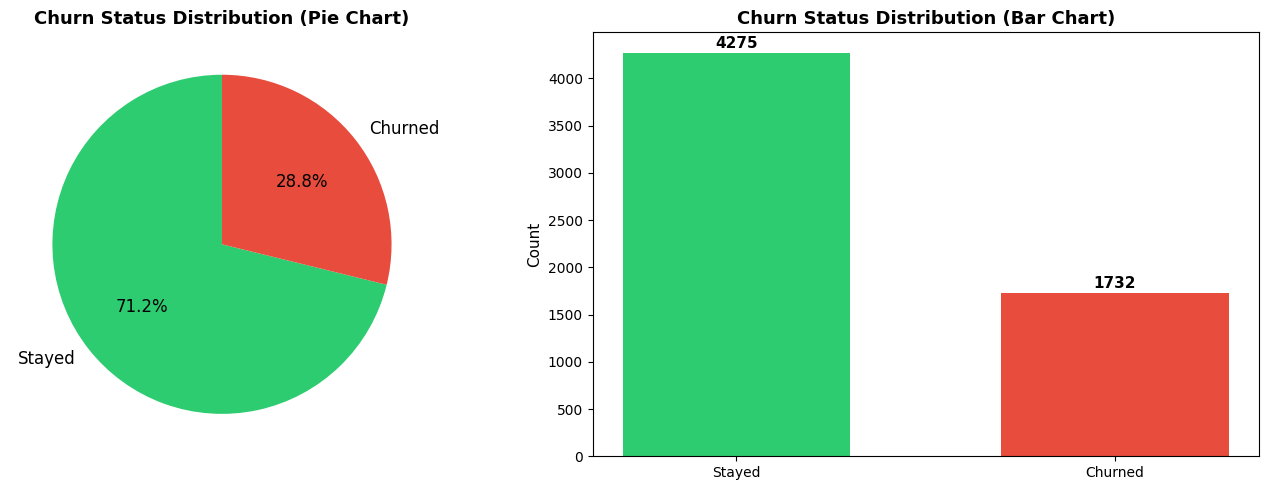

In [6]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
sizes = churn_data["Churn_Status"].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(sizes, labels=['Stayed', 'Churned'], autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Churn Status Distribution (Pie Chart)', fontsize=13, fontweight='bold')

# Bar chart
churn_counts = churn_data["Churn_Status"].value_counts()
axes[1].bar(['Stayed', 'Churned'], churn_counts.values, color=colors, width=0.6)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Churn Status Distribution (Bar Chart)', fontsize=13, fontweight='bold')
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# AGE GROUP vs CHURN

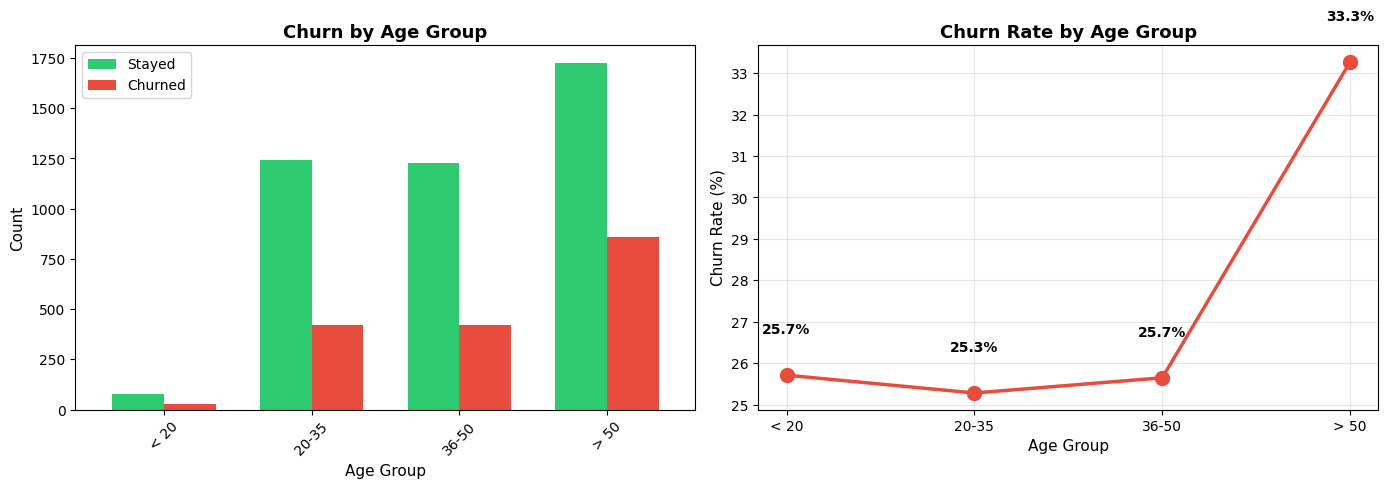

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
age_churn = pd.crosstab(churn_data['Age_Group'], churn_data['Churn_Status'])
age_churn_sorted = age_churn.reindex(['< 20', '20-35', '36-50', '> 50'])
age_churn_sorted.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], width=0.7)
axes[0].set_title('Churn by Age Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(['Stayed', 'Churned'])
axes[0].tick_params(axis='x', rotation=45)

# Churn rate by age group
churn_rate_age = churn_data.groupby('Age_Group')['Churn_Status'].apply(lambda x: (x.sum() / len(x)) * 100)
churn_rate_age_sorted = churn_rate_age.reindex(['< 20', '20-35', '36-50', '> 50'])
axes[1].plot(churn_rate_age_sorted.index, churn_rate_age_sorted.values, marker='o', linewidth=2.5, markersize=10, color='#e74c3c')
axes[1].set_title('Churn Rate by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(churn_rate_age_sorted.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# TENURE GROUP vs CHURN

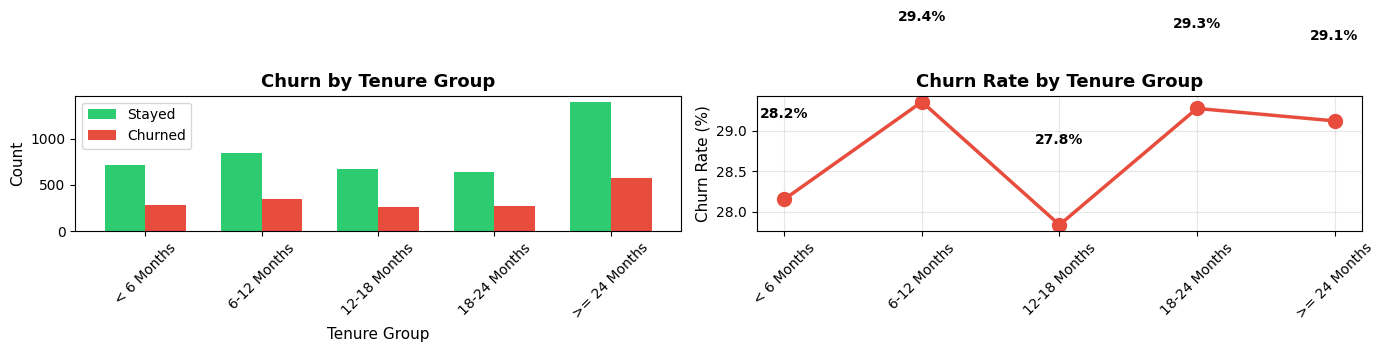

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
tenure_churn = pd.crosstab(churn_data['Tenure_Group'], churn_data['Churn_Status'])
tenure_churn_sorted = tenure_churn.reindex(['< 6 Months', '6-12 Months', '12-18 Months', '18-24 Months', '>= 24 Months'])
tenure_churn_sorted.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], width=0.7)
axes[0].set_title('Churn by Tenure Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure Group', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(['Stayed', 'Churned'])
axes[0].tick_params(axis='x', rotation=45)

# Churn rate by tenure
churn_rate_tenure = churn_data.groupby('Tenure_Group')['Churn_Status'].apply(lambda x: (x.sum() / len(x)) * 100)
churn_rate_tenure_sorted = churn_rate_tenure.reindex(['< 6 Months', '6-12 Months', '12-18 Months', '18-24 Months', '>= 24 Months'])
axes[1].plot(range(len(churn_rate_tenure_sorted)), churn_rate_tenure_sorted.values, marker='o', linewidth=2.5, markersize=10, color='#e74c3c')
axes[1].set_title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(churn_rate_tenure_sorted)))
axes[1].set_xticklabels(churn_rate_tenure_sorted.index, rotation=45)
axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(churn_rate_tenure_sorted.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


# MONTHLY CHARGE RANGE vs CHURN

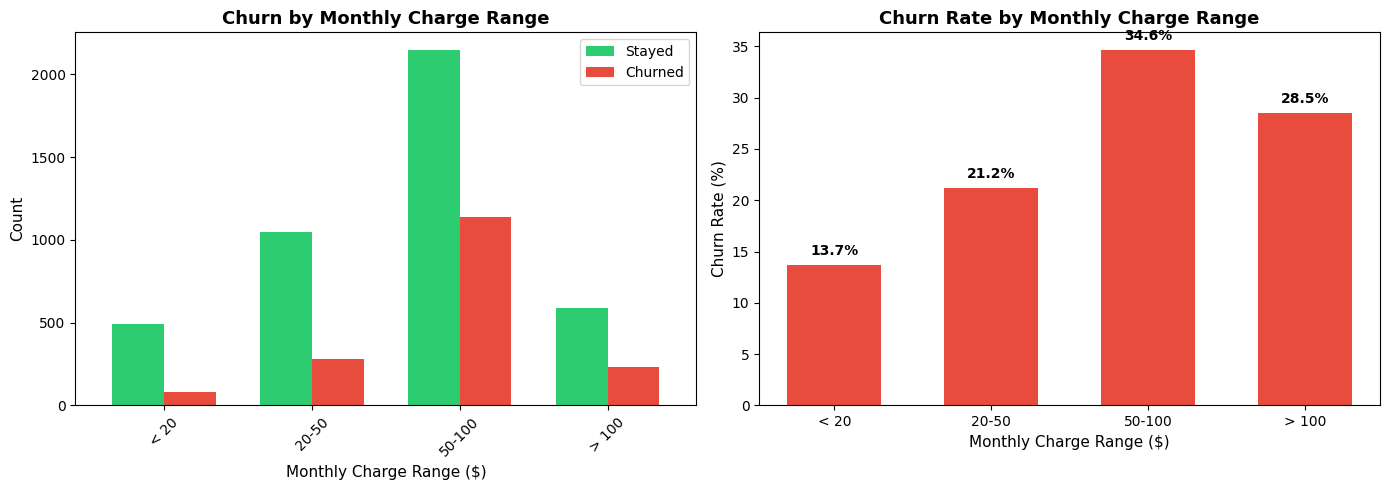

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
charge_churn = pd.crosstab(churn_data['Monthly_Charge_Range'], churn_data['Churn_Status'])
charge_churn_sorted = charge_churn.reindex(['< 20', '20-50', '50-100', '> 100'])
charge_churn_sorted.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], width=0.7)
axes[0].set_title('Churn by Monthly Charge Range', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monthly Charge Range ($)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(['Stayed', 'Churned'])
axes[0].tick_params(axis='x', rotation=45)

# Churn rate by charge
churn_rate_charge = churn_data.groupby('Monthly_Charge_Range')['Churn_Status'].apply(lambda x: (x.sum() / len(x)) * 100)
churn_rate_charge_sorted = churn_rate_charge.reindex(['< 20', '20-50', '50-100', '> 100'])
axes[1].bar(churn_rate_charge_sorted.index, churn_rate_charge_sorted.values, color='#e74c3c', width=0.6)
axes[1].set_title('Churn Rate by Monthly Charge Range', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Monthly Charge Range ($)', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
for i, v in enumerate(churn_rate_charge_sorted.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


#  CONTRACT TYPE vs CHURN

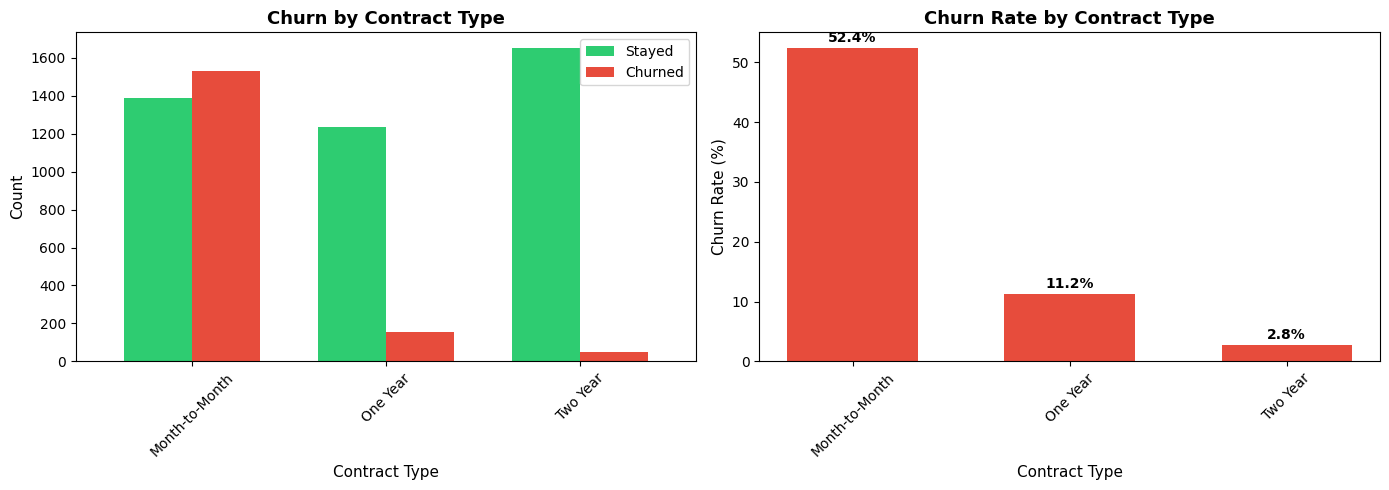

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
contract_churn = pd.crosstab(churn_data['Contract'], churn_data['Churn_Status'])
contract_churn.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], width=0.7)
axes[0].set_title('Churn by Contract Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Contract Type', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(['Stayed', 'Churned'])
axes[0].tick_params(axis='x', rotation=45)

# Churn rate by contract
churn_rate_contract = churn_data.groupby('Contract')['Churn_Status'].apply(lambda x: (x.sum() / len(x)) * 100)
axes[1].bar(churn_rate_contract.index, churn_rate_contract.values, color='#e74c3c', width=0.6)
axes[1].set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Contract Type', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(churn_rate_contract.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


# INTERNET TYPE vs CHURN

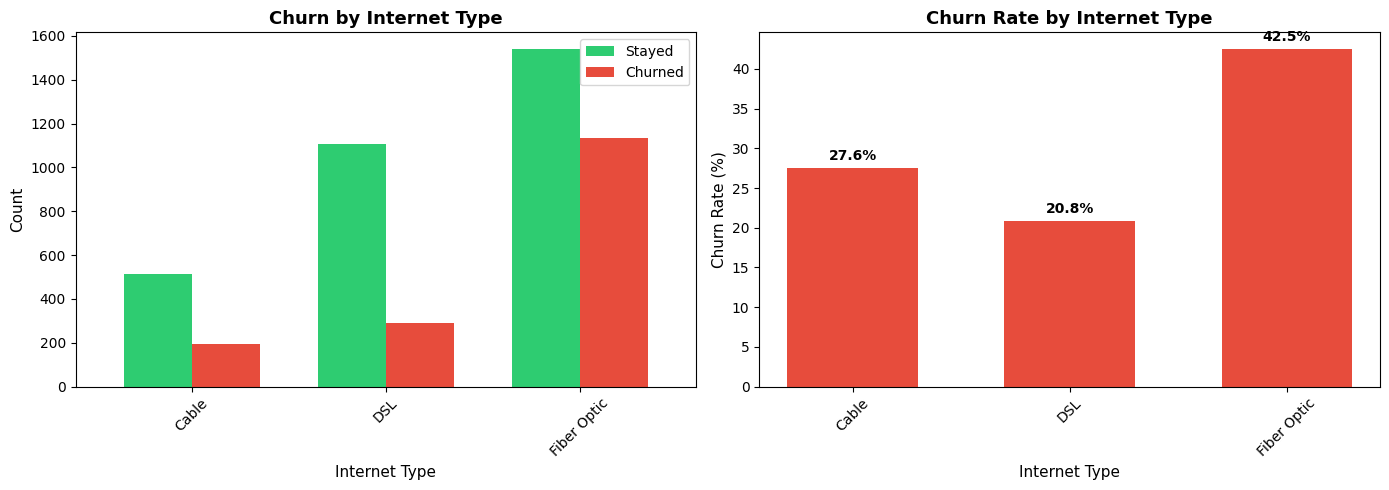

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
internet_churn = pd.crosstab(churn_data['Internet_Type'], churn_data['Churn_Status'])
internet_churn.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], width=0.7)
axes[0].set_title('Churn by Internet Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Internet Type', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(['Stayed', 'Churned'])
axes[0].tick_params(axis='x', rotation=45)

# Churn rate by internet type
churn_rate_internet = churn_data.groupby('Internet_Type')['Churn_Status'].apply(lambda x: (x.sum() / len(x)) * 100)
axes[1].bar(churn_rate_internet.index, churn_rate_internet.values, color='#e74c3c', width=0.6)
axes[1].set_title('Churn Rate by Internet Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Internet Type', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(churn_rate_internet.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


# GENDER & MARRIED STATUS vs CHURN

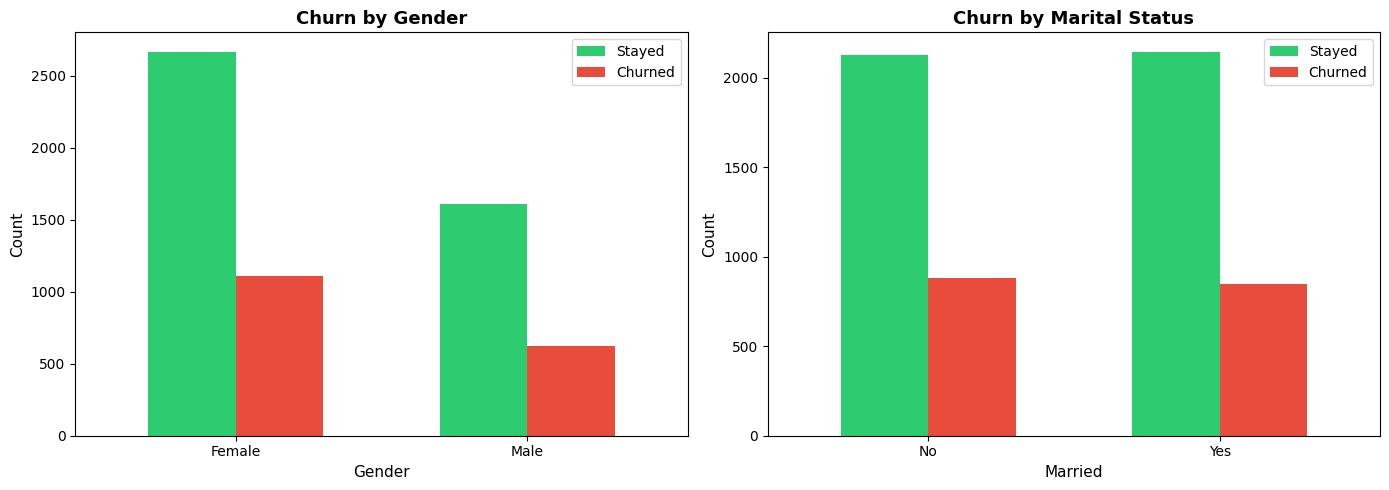

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender churn
gender_churn = pd.crosstab(churn_data['Gender'], churn_data['Churn_Status'])
gender_churn.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], width=0.6)
axes[0].set_title('Churn by Gender', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(['Stayed', 'Churned'])
axes[0].tick_params(axis='x', rotation=0)

# Married status churn
married_churn = pd.crosstab(churn_data['Married'], churn_data['Churn_Status'])
married_churn.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], width=0.6)
axes[1].set_title('Churn by Marital Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Married', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(['Stayed', 'Churned'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()



# NUMERICAL FEATURES DISTRIBUTION vs CHURN

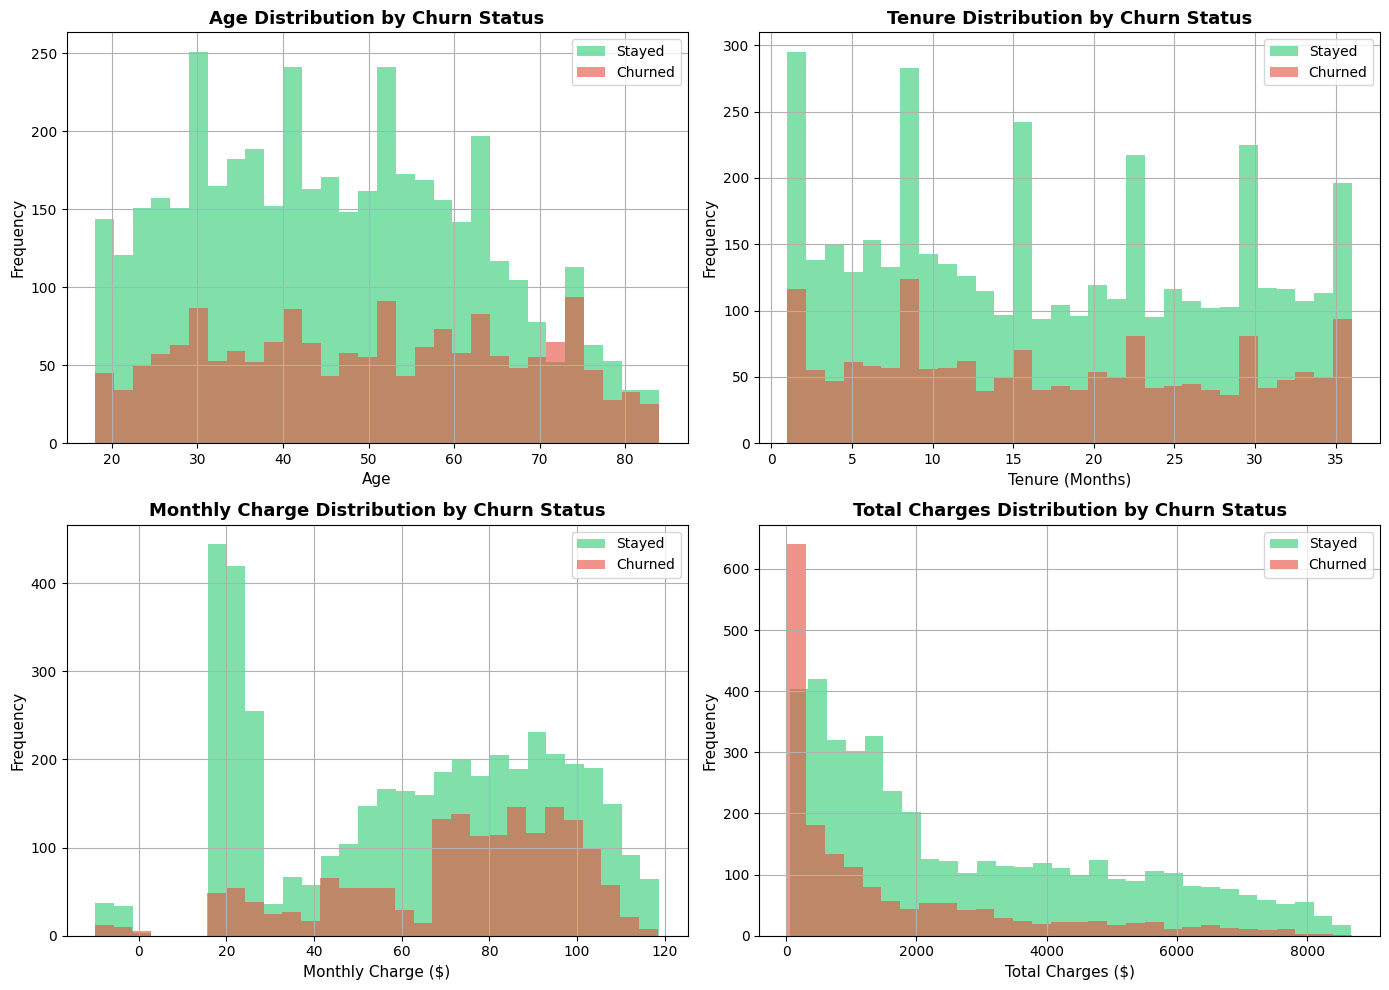

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
churn_data[churn_data['Churn_Status'] == 0]['Age'].hist(bins=30, ax=axes[0, 0], alpha=0.6, label='Stayed', color='#2ecc71')
churn_data[churn_data['Churn_Status'] == 1]['Age'].hist(bins=30, ax=axes[0, 0], alpha=0.6, label='Churned', color='#e74c3c')
axes[0, 0].set_title('Age Distribution by Churn Status', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Age', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].legend()

# Tenure distribution
churn_data[churn_data['Churn_Status'] == 0]['Tenure_in_Months'].hist(bins=30, ax=axes[0, 1], alpha=0.6, label='Stayed', color='#2ecc71')
churn_data[churn_data['Churn_Status'] == 1]['Tenure_in_Months'].hist(bins=30, ax=axes[0, 1], alpha=0.6, label='Churned', color='#e74c3c')
axes[0, 1].set_title('Tenure Distribution by Churn Status', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Tenure (Months)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].legend()

# Monthly charge distribution
churn_data[churn_data['Churn_Status'] == 0]['Monthly_Charge'].hist(bins=30, ax=axes[1, 0], alpha=0.6, label='Stayed', color='#2ecc71')
churn_data[churn_data['Churn_Status'] == 1]['Monthly_Charge'].hist(bins=30, ax=axes[1, 0], alpha=0.6, label='Churned', color='#e74c3c')
axes[1, 0].set_title('Monthly Charge Distribution by Churn Status', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Monthly Charge ($)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].legend()

# Total charges distribution
churn_data[churn_data['Churn_Status'] == 0]['Total_Charges'].hist(bins=30, ax=axes[1, 1], alpha=0.6, label='Stayed', color='#2ecc71')
churn_data[churn_data['Churn_Status'] == 1]['Total_Charges'].hist(bins=30, ax=axes[1, 1], alpha=0.6, label='Churned', color='#e74c3c')
axes[1, 1].set_title('Total Charges Distribution by Churn Status', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Total Charges ($)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

#  BOX PLOTS - NUMERICAL FEATURES

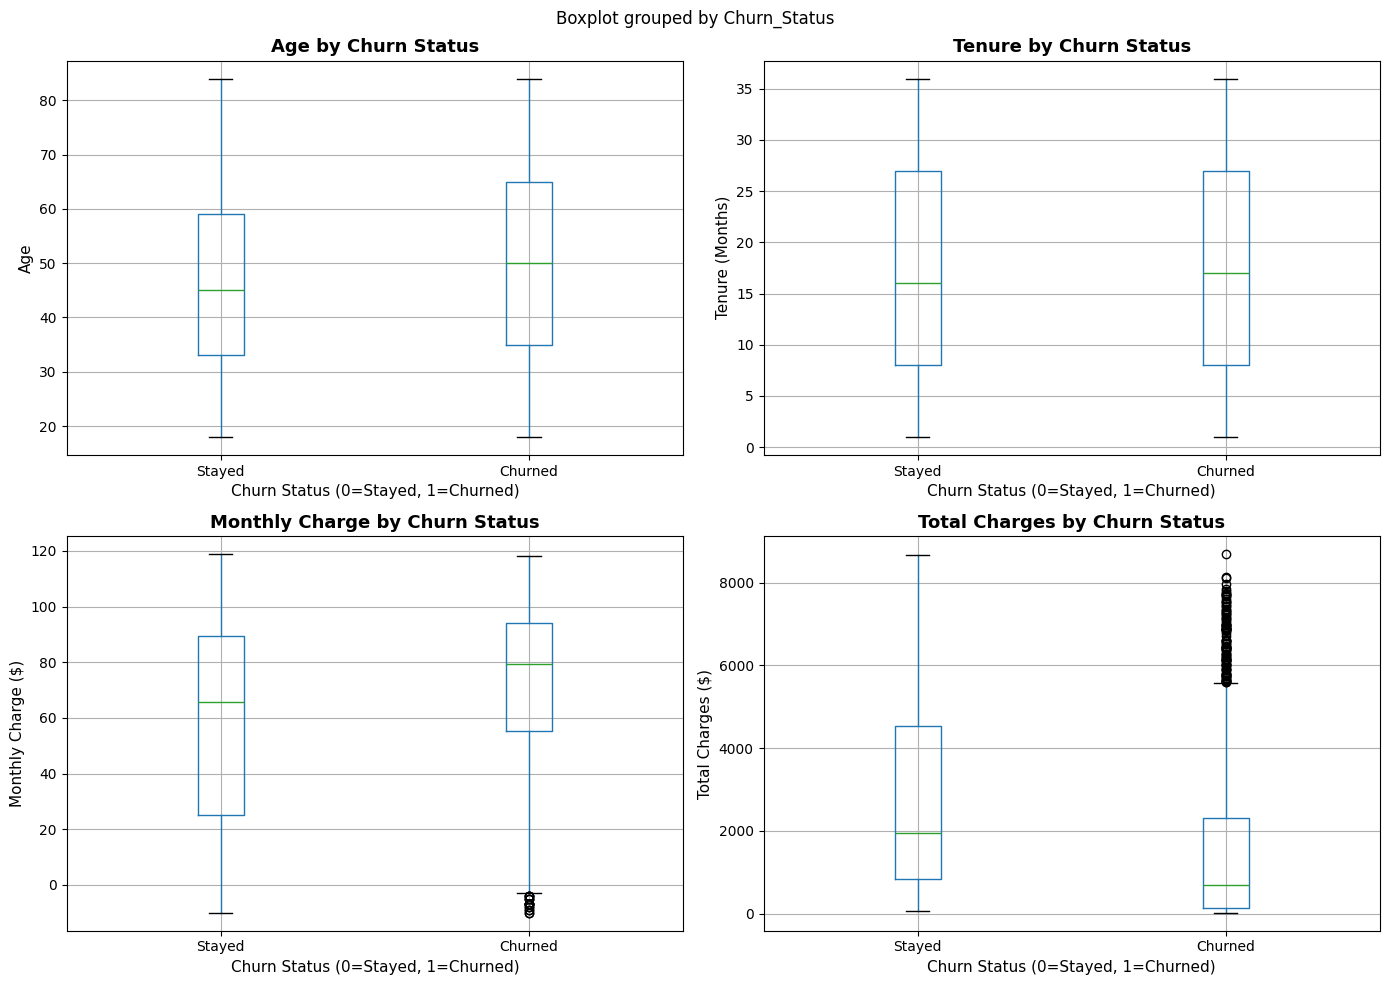

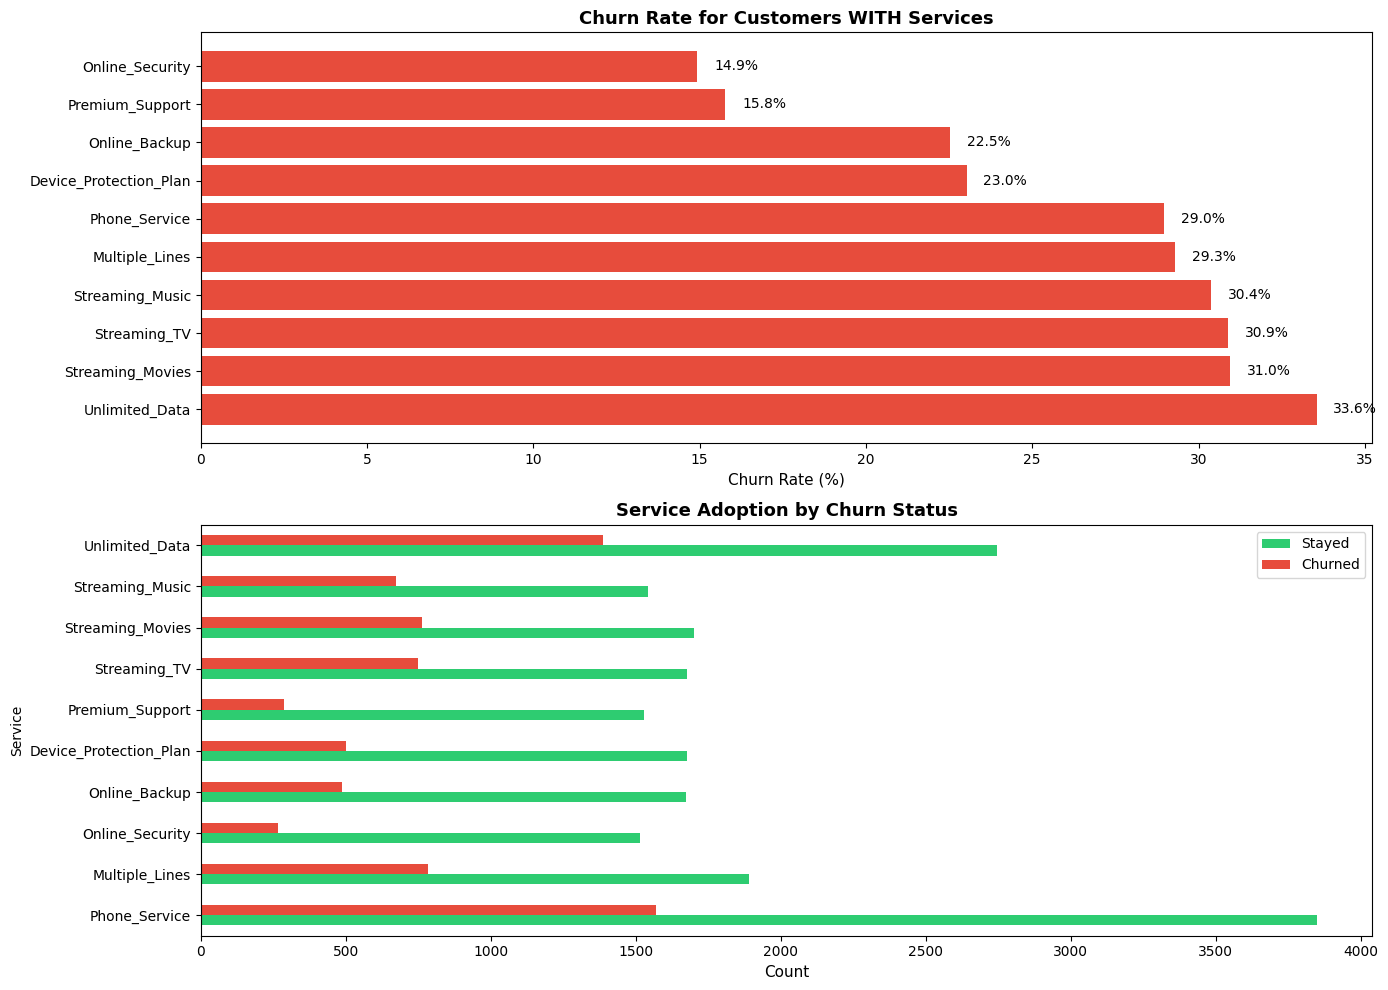

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age boxplot
churn_data.boxplot(column='Age', by='Churn_Status', ax=axes[0, 0])
axes[0, 0].set_title('Age by Churn Status', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Churn Status (0=Stayed, 1=Churned)', fontsize=11)
axes[0, 0].set_ylabel('Age', fontsize=11)
plt.sca(axes[0, 0])
plt.xticks([1, 2], ['Stayed', 'Churned'])

# Tenure boxplot
churn_data.boxplot(column='Tenure_in_Months', by='Churn_Status', ax=axes[0, 1])
axes[0, 1].set_title('Tenure by Churn Status', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Churn Status (0=Stayed, 1=Churned)', fontsize=11)
axes[0, 1].set_ylabel('Tenure (Months)', fontsize=11)
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['Stayed', 'Churned'])

# Monthly charge boxplot
churn_data.boxplot(column='Monthly_Charge', by='Churn_Status', ax=axes[1, 0])
axes[1, 0].set_title('Monthly Charge by Churn Status', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Churn Status (0=Stayed, 1=Churned)', fontsize=11)
axes[1, 0].set_ylabel('Monthly Charge ($)', fontsize=11)
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Stayed', 'Churned'])

# Total charges boxplot
churn_data.boxplot(column='Total_Charges', by='Churn_Status', ax=axes[1, 1])
axes[1, 1].set_title('Total Charges by Churn Status', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Churn Status (0=Stayed, 1=Churned)', fontsize=11)
axes[1, 1].set_ylabel('Total Charges ($)', fontsize=11)
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Stayed', 'Churned'])

plt.tight_layout()
plt.show()

# =========================
# 10. SERVICES ADOPTION vs CHURN
# =========================

services = ['Phone_Service', 'Multiple_Lines', 'Online_Security', 'Online_Backup', 
            'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 
            'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Service adoption rate
service_churn_rate = {}
for service in services:
    if service in churn_data.columns:
        service_yes = churn_data[churn_data[service] == 'Yes']['Churn_Status'].mean() * 100
        service_churn_rate[service] = service_yes

service_churn_df = pd.DataFrame(list(service_churn_rate.items()), columns=['Service', 'Churn_Rate'])
service_churn_df = service_churn_df.sort_values('Churn_Rate', ascending=False)

axes[0].barh(service_churn_df['Service'], service_churn_df['Churn_Rate'], color='#e74c3c')
axes[0].set_title('Churn Rate for Customers WITH Services', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn Rate (%)', fontsize=11)
for i, v in enumerate(service_churn_df['Churn_Rate'].values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

# Service count by churn status
service_counts = []
for service in services:
    if service in churn_data.columns:
        stayed = len(churn_data[(churn_data[service] == 'Yes') & (churn_data['Churn_Status'] == 0)])
        churned = len(churn_data[(churn_data[service] == 'Yes') & (churn_data['Churn_Status'] == 1)])
        service_counts.append({'Service': service, 'Stayed': stayed, 'Churned': churned})

service_counts_df = pd.DataFrame(service_counts)
service_counts_df.set_index('Service')[['Stayed', 'Churned']].plot(kind='barh', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Service Adoption by Churn Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count', fontsize=11)
axes[1].legend(['Stayed', 'Churned'])

plt.tight_layout()
plt.show()

